# Laboratorio 6 — Análisis de redes sociales (YouTube)

**CC3084 — Data Science | UVG**

Este notebook contiene el desarrollo del laboratorio de análisis de redes sociales usando dos conjuntos de datos de YouTube: `youtube_videos.csv` y `youtube_comments.csv`.

En cada sección se explica primero, en términos sencillos, **qué vamos a hacer y por qué**, y luego se muestra el código y los resultados.

## Preparación del entorno



In [ ]:
import pandas as pd
import numpy as np
import re
import ast
import warnings

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)


COLOR_NARANJA_OSCURO = '#B8481F'
COLOR_NARANJA_CLARO  = '#E89A45'
COLOR_VERDE_OSCURO   = '#1F7A3D'
COLOR_VERDE_CLARO    = '#7CB869'
COLOR_NEUTRO         = '#9A9A93'   


PALETA_CATEGORICA = [COLOR_NARANJA_OSCURO, COLOR_NARANJA_CLARO, COLOR_VERDE_OSCURO, COLOR_VERDE_CLARO]


CMAP_VERDE_SECUENCIAL = LinearSegmentedColormap.from_list(
    'verde_secuencial',
    ['#EAF6E8', '#C3E6BB', '#9AD48C', '#7CB869', '#4C9A4F', '#1F7A3D']
)

sns.set_theme(style='whitegrid', rc={
    'axes.edgecolor': '#4d4d4d',
    'axes.labelcolor': '#2b2b2b',
    'text.color': '#2b2b2b',
    'xtick.color': '#4d4d4d',
    'ytick.color': '#4d4d4d',
    'grid.color': '#e6e6e2',
    'figure.facecolor': '#fcfcfb',
    'axes.facecolor': '#fcfcfb',
})
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10.5

print('Librerías cargadas y paleta de colores lista.')

Librerías cargadas y paleta de colores lista.


## 1. Carga, comprensión e integración de los datos

### 1.1 Carga de los archivos


In [ ]:
# Cargamos ambos archivos indicando skipinitialspace=True para resolver
videos = pd.read_csv('youtube_videos.csv', encoding='utf-8-sig', skipinitialspace=True)
comments = pd.read_csv('youtube_comments.csv', encoding='utf-8-sig', skipinitialspace=True)


videos.columns = videos.columns.str.strip()
comments.columns = comments.columns.str.strip()

print(f'youtube_videos.csv   -> {videos.shape[0]} filas, {videos.shape[1]} columnas')
print(f'youtube_comments.csv -> {comments.shape[0]} filas, {comments.shape[1]} columnas')

youtube_videos.csv   -> 293 filas, 20 columnas
youtube_comments.csv -> 406 filas, 17 columnas


In [3]:
# Primer vistazo a youtube_videos.csv
videos.info()
videos.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   video_id             293 non-null    str  
 1   title                293 non-null    str  
 2   channel_name         293 non-null    str  
 3   channel_id           293 non-null    str  
 4   source_query         293 non-null    str  
 5   source_group         293 non-null    str  
 6   dataset_sources      293 non-null    str  
 7   channel_handle       293 non-null    str  
 8   published_time       280 non-null    str  
 9   view_count_text      280 non-null    str  
 10  description_snippet  268 non-null    str  
 11  video_url            293 non-null    str  
 12  query_hits           293 non-null    str  
 13  keywords             293 non-null    str  
 14  description          267 non-null    str  
 15  view_count           293 non-null    int64
 16  publish_date         293 non-null    

,video_id,title,channel_name,channel_id,source_query,source_group,dataset_sources,channel_handle,published_time,view_count_text,description_snippet,video_url,query_hits,keywords,description,view_count,publish_date,upload_date,category,owner_handle
0,-5puKGEqcUc,INSIVUMEH pronostica incremento de lluvias par...,T13 Noticias Guatemala,UCq0Cm-3SKthEySQc2JZBi1A,guatemala lluvias,topic,youtube_guatemala.csv | youtube_guatemala_lab....,/@T13NoticiasGuatemala,hace 2 días,"2,390 vistas",El Departamento de Pronóstico de INSIVUMEH pre...,https://www.youtube.com/watch?v=-5puKGEqcUc,"[""guatemala lluvias""]","[""Canícula prolongada"", ""Chapin tv"", ""Fenómeno...",El Departamento de Pronóstico de INSIVUMEH pre...,2357,2026-08-28T22:00:20-07:00,2026-08-28T22:00:20-07:00,News & Politics,/@T13NoticiasGuatemala
1,-E7OPOLjMug,BERNARDO ARÉVALO CALIFICA CAMBIO EN EL MP COMO...,IDocumenta,UCgItjn_ZWFWcv1MlpKIkqgQ,@GobiernodelaRepublicadeGuatema,topic,youtube_target_channels.csv,/@iDocumenta,hace 3 meses,4 vistas,"El presidente de Guatemala, Bernardo Arévalo, ...",https://www.youtube.com/watch?v=-E7OPOLjMug,"[""@GobiernodelaRepublicadeGuatema""]",[],"El presidente de Guatemala, Bernardo Arévalo, ...",4,2026-05-13T16:00:03-07:00,2026-05-13T16:00:03-07:00,People & Blogs,/@iDocumenta
2,-KDglrIzRKo,¡HISTÓRICO! Mexico recupera petróleo robado po...,México Poder,UC-DpoeBbCMOMOH1-j71KPqA,guatemala noticias,topic,youtube_guatemala.csv | youtube_guatemala_lab....,/@M%C3%A9xicoPoder,hace 1 día,"29,736 vistas",México #PetróleoMexicano #SoberaníaEnergética ...,https://www.youtube.com/watch?v=-KDglrIzRKo,"[""guatemala noticias""]","[""Mexico recupera petroleo"", ""petroleo robado ...",#México #PetróleoMexicano #SoberaníaEnergética...,29736,2026-08-29T17:00:38-07:00,2026-08-29T17:00:38-07:00,People & Blogs,/@M%C3%A9xicoPoder


In [4]:
# Primer vistazo a youtube_comments.csv
comments.info()
comments.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   video_id           406 non-null    str    
 1   comment_id         406 non-null    str    
 2   video_title        406 non-null    str    
 3   channel_name       406 non-null    str    
 4   channel_id         406 non-null    str    
 5   author_name        406 non-null    str    
 6   author_channel_id  406 non-null    str    
 7   text               406 non-null    str    
 8   source_query       406 non-null    str    
 9   source_group       406 non-null    str    
 10  dataset_sources    406 non-null    str    
 11  author_handle      406 non-null    str    
 12  published_text     406 non-null    str    
 13  like_count_text    217 non-null    float64
 14  reply_count        406 non-null    int64  
 15  is_pinned          406 non-null    str    
 16  viewer_rating      0 non-null      fl

,video_id,comment_id,video_title,channel_name,channel_id,author_name,author_channel_id,text,source_query,source_group,dataset_sources,author_handle,published_text,like_count_text,reply_count,is_pinned,viewer_rating
0,j43HgwYFKfk,Ugw-J65a1iYL9hqhELh4AaABAg,La cooptación de Walter Mazariegos en la USAC ...,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@MarcosCarillo-b1r,UCdFlugHJJa4l3YqWuNRmvXw,Ese corrupto amigo de la vieja fiscal los teng...,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete...,/@MarcosCarillo-b1r,hace 6 meses,NaN,0,False,NaN
1,06mFNPU0aB8,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,Capturan a presuntos delincuentes disfrazados ...,Noti7,UCVpSRoZgngfSL03Nlbjtq9A,@RaulPerez-cw2vi,UCvl1tzQeBeGy6efPTRJXSCw,"Están jóvenes porque no buscan un trabajo, tu...",guatemala noticias,topic,youtube_guatemala_comments.csv | youtube_guate...,/@RaulPerez-cw2vi,hace 2 semanas,NaN,0,False,NaN
2,j43HgwYFKfk,Ugw0xaOb2CYXXoudtwJ4AaABAg,La cooptación de Walter Mazariegos en la USAC ...,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@iamjimalesssa,UCRAquv8el-tQ30bN7MlmySQ,Me dejaron con ganas de demandar la ilegalidad...,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete...,/@iamjimalesssa,hace 1 año,4.0,0,False,NaN


### 1.2 Unidad de observación, llave primaria y variables relevantes


**`youtube_videos.csv`**
- **Unidad de observación:** un video publicado en YouTube.
- **Llave primaria:** `video_id` 
- **Variables más relevantes para el laboratorio:**
  - Para identidad/relación: `video_id`, `channel_id` (el canal, más estable que `channel_name`, que sí puede repetirse o cambiar).
  - Para popularidad: `view_count` (numérico, listo para cálculos; `view_count_text` es solo el texto que muestra YouTube).
  - Para clasificación temática: `category`, `source_query`, `source_group`, `keywords`, `query_hits`.
  - Para texto: `title`, `description`.
  - Para tiempo: `publish_date` (fecha real ISO 8601); `published_time` es relativo ("hace 2 días") y depende del momento en que se recolectaron los datos, no lo usaremos como fecha exacta.

**`youtube_comments.csv`**
- **Unidad de observación:** un comentario principal publicado en un video (no incluye respuestas a comentarios).
- **Llave primaria:** `comment_id` (también verificado sin duplicados).
- **Llave foránea:** `video_id`, que conecta cada comentario con su video en `youtube_videos.csv`.
- **Variables más relevantes:**
  - Para identidad del autor: `author_channel_id` (el "DNI" del autor; `author_name` y `author_handle` son solo visibles y pueden repetirse o cambiar).
  - Para contenido: `text` (el comentario en sí).
  - Para popularidad del comentario: `like_count_text` (texto, hay que limpiarlo) y `reply_count` (número de respuestas, **no** identifica quién respondió).
  - Variables que **no aportan nada** en este conjunto: `is_pinned` (siempre `False`) y `viewer_rating` (siempre vacía) — lo confirmamos en la sección 2.

Confirmamos abajo que ambas llaves primarias son únicas (0 duplicados).

In [5]:
# Verificación de llaves primarias
print('Duplicados en video_id (videos):    ', videos['video_id'].duplicated().sum())
print('Duplicados en comment_id (comments):', comments['comment_id'].duplicated().sum())
print()
print('Canales únicos (channel_id) en videos:  ', videos['channel_id'].nunique())
print('Autores únicos (author_channel_id):     ', comments['author_channel_id'].nunique())
print()
print('¿is_pinned siempre False?  ', (comments['is_pinned'] == False).all())
print('¿viewer_rating siempre vacío?', comments['viewer_rating'].isna().all())

Duplicados en video_id (videos):     0
Duplicados en comment_id (comments): 0

Canales únicos (channel_id) en videos:   97
Autores únicos (author_channel_id):      332

¿is_pinned siempre False?   False
¿viewer_rating siempre vacío? True


### 1.3 Relación entre canal, video, autor, comentario, categoría y consulta de búsqueda


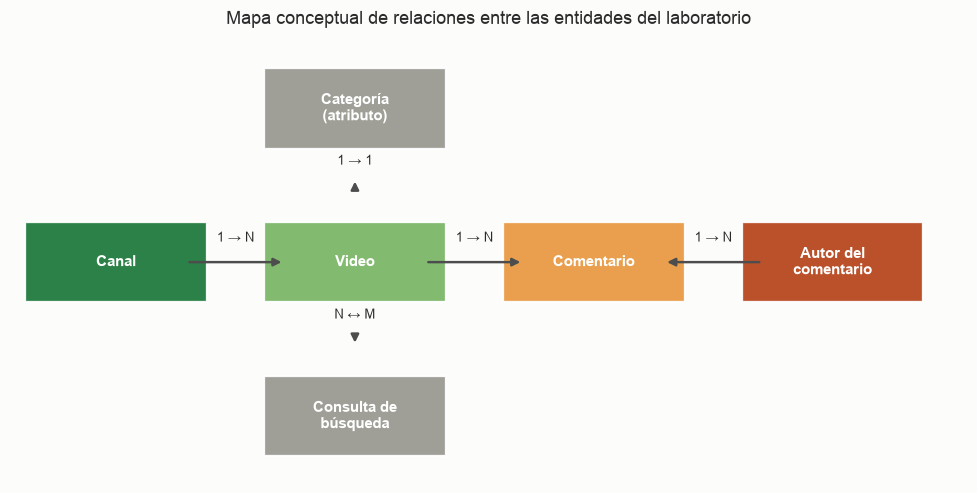

In [ ]:
# Esquema conceptual de relaciones 
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')

boxes = {
    'Canal':               (1.1, 3, COLOR_VERDE_OSCURO),
    'Video':                (3.6, 3, COLOR_VERDE_CLARO),
    'Comentario':           (6.1, 3, COLOR_NARANJA_CLARO),
    'Autor del\ncomentario': (8.6, 3, COLOR_NARANJA_OSCURO),
    'Categoría\n(atributo)': (3.6, 5.1, COLOR_NEUTRO),
    'Consulta de\nbúsqueda':  (3.6, 0.9, COLOR_NEUTRO),
}

for label, (x, y, color) in boxes.items():
    ax.add_patch(plt.Rectangle((x-0.95, y-0.55), 1.9, 1.1, facecolor=color,
                                edgecolor='white', linewidth=1.5, alpha=0.95, zorder=2))
    ax.text(x, y, label, ha='center', va='center', color='white', fontsize=9.5,
            fontweight='bold', zorder=3)

def arrow(p1, p2, text=''):
    x1, y1, _ = boxes[p1]
    x2, y2, _ = boxes[p2]
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='-|>', color='#4d4d4d', lw=1.6,
                                 shrinkA=48, shrinkB=48))
    ax.text((x1+x2)/2, (y1+y2)/2 + 0.28, text, ha='center', fontsize=8.5, color='#2b2b2b')

arrow('Canal', 'Video', '1 → N')
arrow('Video', 'Comentario', '1 → N')
arrow('Autor del\ncomentario', 'Comentario', '1 → N')
arrow('Video', 'Categoría\n(atributo)', '1 → 1')
arrow('Video', 'Consulta de\nbúsqueda', 'N ↔ M')

ax.set_title('Mapa conceptual de relaciones entre las entidades del laboratorio',
              fontsize=11.5, color='#2b2b2b', pad=12)
plt.tight_layout()
plt.show()

### 1.4 Integración de los conjuntos mediante `video_id`

 Queremos comprobar dos cosas: (1) que **todo** comentario logre encontrar su video correspondiente, y (2) qué tan repartidos están esos comentarios entre los 293 videos disponibles.

In [ ]:

comments_full = comments.merge(
    videos,
    on='video_id',
    how='left',
    suffixes=('_comment', '_video'),
    indicator=True
)

print('Resultado de la integración (indicator de merge):')
print(comments_full['_merge'].value_counts())
print()

n_match = (comments_full['_merge'] == 'both').sum()
print(f'Comentarios asociados exitosamente a un video: {n_match} de {len(comments)} '
      f'({n_match/len(comments):.1%})')

comments_full = comments_full.drop(columns='_merge')

Resultado de la integración (indicator de merge):
_merge
both          406
left_only       0
right_only      0
Name: count, dtype: int64

Comentarios asociados exitosamente a un video: 406 de 406 (100.0%)


In [8]:
# ¿Cuántos de los 293 videos realmente tienen al menos un comentario en este conjunto?
videos_con_comentarios = comments['video_id'].nunique()
videos_totales = videos['video_id'].nunique()
videos_sin_comentarios = videos_totales - videos_con_comentarios

print(f'Videos con al menos 1 comentario: {videos_con_comentarios} de {videos_totales} '
      f'({videos_con_comentarios/videos_totales:.1%})')
print(f'Videos sin ningún comentario en este conjunto: {videos_sin_comentarios} '
      f'({videos_sin_comentarios/videos_totales:.1%})')

Videos con al menos 1 comentario: 19 de 293 (6.5%)
Videos sin ningún comentario en este conjunto: 274 (93.5%)
